Q3 - Feature Engineering and Regression Pipeline

In [1]:
#importing required libraries
import pandas as pd
import numpy as np

#for preprocessing and pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

#evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error

#for plotting
import matplotlib.pyplot as plt

In [3]:
#loading the csv file
df = pd.read_csv('../data/q3_retail_promotions.csv')

#seeing first few rows
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [ ]:
#Date Feature Engineering
#converting transaction_date to datetime format
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

#extracting year, month, day of week
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek  # monday = 0

#creating is_month_end column
#if day >= 25 then 1 else 0
df['is_month_end'] = df['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

#displaying sample data
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


In [5]:
#Temporal Train-Test Split
#sorting data based on date
df = df.sort_values(by='transaction_date')

#splitting 80% train and 20% test
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

#checking shapes
print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (960, 13)
Test size: (240, 13)


Random split is not correct for time based data because it mixes past and future data.
In real life, we predict future using past data only.

If we use random split, model may learn from future data which gives wrong performance.
So we use time based split to simulate real scenario.

In [6]:
#Separate Features and Target

#target column
target = 'items_sold'

#dropping unnecessary column
X_train = train_df.drop(columns=[target, 'transaction_date'])
y_train = train_df[target]

X_test = test_df.drop(columns=[target, 'transaction_date'])
y_test = test_df[target]

In [7]:
#Preprocessing Pipeline
#categorical columns
categorical_cols = ['promotion_type', 'location_type', 'store_size']

#numerical columns
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

#creating transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

In [ ]:
#Model Training and Evaluation

#Linear Regression Pipeline
#creating pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])

#training model
lr_pipeline.fit(X_train, y_train)

#predictions
y_pred_lr = lr_pipeline.predict(X_test)

#evaluation
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression MAE:", mae_lr)

Linear Regression RMSE: 27.121451164890637
Linear Regression MAE: 21.052926674588395


In [9]:
#Random Forest Pipeline

#creating pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

#training model
rf_pipeline.fit(X_train, y_train)

#predictions
y_pred_rf = rf_pipeline.predict(X_test)

#evaluation
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)

Random Forest RMSE: 30.841610008504205
Random Forest MAE: 24.240625


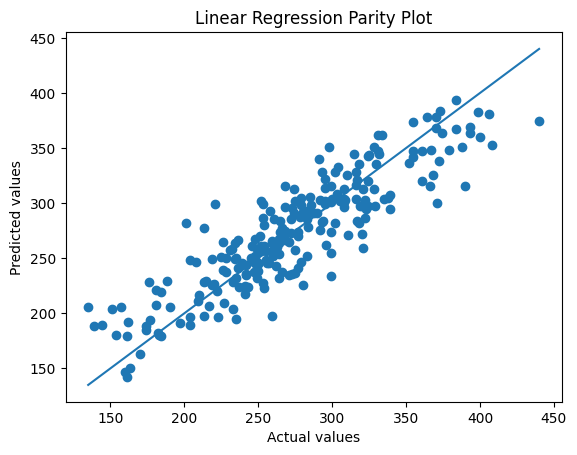

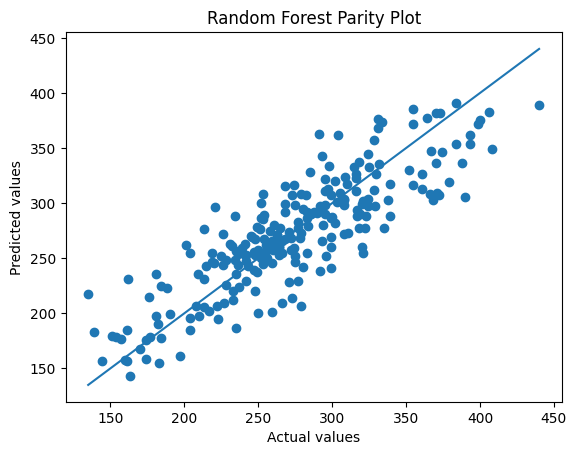

In [10]:
#Parity Plot (Predicted vs Actual)

#function to plot parity plot
def plot_parity(y_true, y_pred, title):
    plt.figure()
    plt.scatter(y_true, y_pred)
    plt.xlabel("Actual values")
    plt.ylabel("Predicted values")
    plt.title(title)
    
    #drawing diagonal line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val])
    
    plt.show()

#plotting for both models
plot_parity(y_test, y_pred_lr, "Linear Regression Parity Plot")
plot_parity(y_test, y_pred_rf, "Random Forest Parity Plot")

In [11]:
#Feature Importance (Random Forest)

#getting feature names after one-hot encoding
ohe = rf_pipeline.named_steps['preprocessing'].named_transformers_['cat']
encoded_cat_features = ohe.get_feature_names_out(categorical_cols)

#combining all feature names
all_features = list(encoded_cat_features) + numerical_cols

#getting feature importance
importances = rf_pipeline.named_steps['model'].feature_importances_

#creating dataframe for easy understanding
feature_importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
})

#sorting
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

#printing top 5 features
print("Top 5 important features:")
print(feature_importance_df.head(5))

Top 5 important features:
                feature  importance
13          is_festival    0.173473
10     store_size_small    0.167683
7   location_type_urban    0.108378
17          day_of_week    0.086316
12           is_weekend    0.061208
